In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import math
sys.path.append('../')
from Scattering_Simulator import pairwise_method, fitting
from Scattering_Simulator import Read_PDB
from genetic_algorithm import GA_functions as GA
from genetic_algorithm import curve_fitting as cf
from scipy import integrate
import torch 
import warnings
warnings.filterwarnings("ignore")

## Fitting

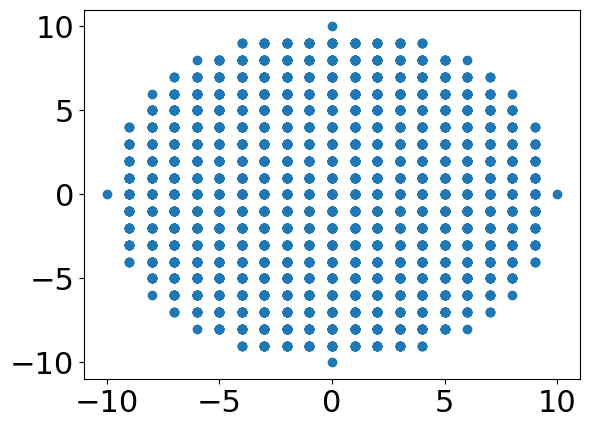

In [21]:
d = 20 
sphere = pairwise_method.generate_sphere(diameter=d, spacing=d/20)
plt.scatter(sphere[:,0], sphere[:,1])

In [2]:
def generate_spheres_from_distribution(mean, std, num_bins=10, spacing=0.2, seed=None):
    """
    Generate sphere objects and proportions from a normal distribution.

    Parameters:
        mean (float): mean diameter
        std (float): standard deviation of diameter
        num_bins (int): number of discrete sphere sizes
        spacing (float): resolution of sphere points
        seed (int or None): random seed

    Returns:
        objects (list of ndarray): sphere coordinate arrays
        proportions (list of float): corresponding probabilities
        diameters (ndarray): sampled diameters
    """
    if seed is not None:
        np.random.seed(seed)

    # Sample diameters from normal distribution
    diameters = np.random.normal(mean, std, size=10000)

    # Remove non-physical (negative) diameters
    diameters = diameters[diameters > 0]

    # Bin the diameters
    hist, bin_edges = np.histogram(diameters, bins=num_bins, density=True)

    # Convert histogram to probabilities
    proportions = hist / hist.sum()

    # Representative diameter for each bin (bin center)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Generate sphere objects
    objects = []
    for d in bin_centers:
        sphere = pairwise_method.generate_sphere(diameter=d, spacing=spacing)
        objects.append(sphere)

    return objects, proportions.tolist(), bin_centers

In [3]:
objects, proportions, diameters = generate_spheres_from_distribution(
    mean=10.0,
    std=3,
    num_bins=10,
    spacing=0.2,
    seed=42
)

print("Diameters:", diameters)
print("Proportions:", proportions)
print("Number of sphere types:", len(objects))

Diameters: [ 1.35062125  3.50094671  5.65127217  7.80159763  9.95192309 12.10224855
 14.25257401 16.40289947 18.55322493 20.70355039]
Proportions: [0.005702280912364946, 0.03011204481792717, 0.10174069627851141, 0.2174869947979192, 0.2816126450580232, 0.21758703481392558, 0.10834333733493397, 0.030312124849939975, 0.006602641056422575, 0.0005002000800320124]
Number of sphere types: 10


In [14]:
diameters

array([ 1.35062125,  3.50094671,  5.65127217,  7.80159763,  9.95192309,
       12.10224855, 14.25257401, 16.40289947, 18.55322493, 20.70355039])

In [4]:
lattice_coords = pairwise_method.generate_coordinates_for_polydisperse_system(size_of_object=12)

In [4]:
sphere1 = pairwise_method.generate_sphere(10)
sphere2 = pairwise_method.generate_sphere(20)
sphere3 = pairwise_method.generate_sphere(30)
sphere4 = pairwise_method.generate_sphere(40)
sphere5 = pairwise_method.generate_sphere(50)

In [5]:
# proportions = [0.2, 0.2, 0.2, 0.2, 0.2]
# objects = [sphere1, sphere2, sphere3, sphere4, sphere5]
all_coords = pairwise_method.place_objects_on_coordinates(lattice_coords, objects, proportions)

In [23]:
lattice_coords.shape

(216, 3)

In [25]:
len(objects)

10

In [26]:
len(proportions)

10

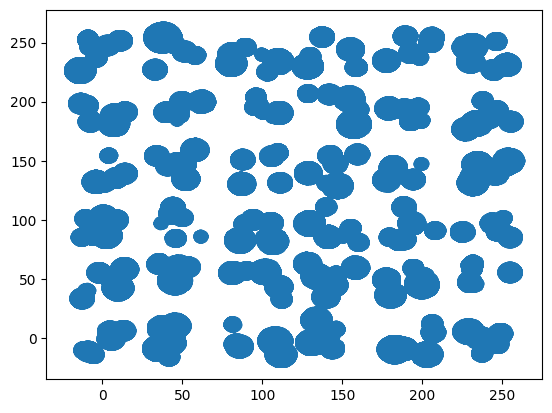

In [6]:
plt.scatter(all_coords[::10,0], all_coords[::10,2])

In [7]:
n_samples = 10000000
simulator = pairwise_method.scattering_simulator(n_samples)
simulator.sample_building_block(all_coords)
simulator.use_building_block_as_structure()

In [ ]:
histogram_bins = 10000
q = np.geomspace(0.01, 10, 300)
I_q = simulator.simulate_scattering_curve(histogram_bins, q)

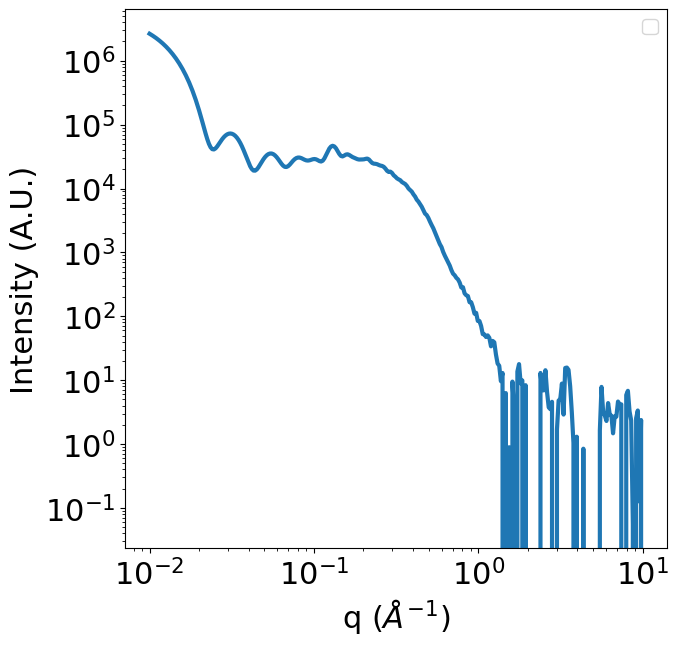

In [11]:
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7))
plt.plot(q, I_q, linewidth = 3)
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Intensity (A.U.)')
plt.xlabel('q ($\AA^{-1}$)')
plt.legend(fontsize=14)
plt.show()

In [13]:
data = np.hstack((q.reshape(-1,1), I_q.reshape(-1,1)))
np.savetxt("output.txt", data)

In [37]:
np.sqrt(3)

np.float64(1.7320508075688772)

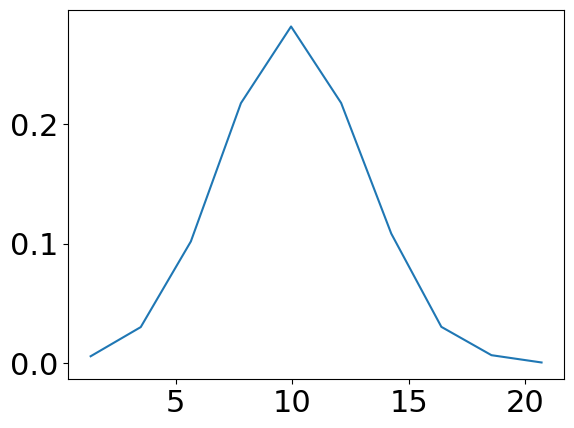

In [12]:
plt.plot(diameters, proportions)